# Toxic maker-flow filtering: walk-forward backtest

End-to-end backtest of the PnL-based toxic-flow filter on BTC perps.

**Pipeline.** A regression model predicts the per-trade markout PnL (`pnl_{tau}s`, rebate included); toxicity is the negated prediction. On each walk-forward window the model is trained on `train_model`, the filter threshold is tuned on `calib` (exact vectorized sweep, subject to the filter-rate budget and the turnover floor), and the filter is evaluated on the out-of-sample `test` month.

**Score.** `score = pnl_kept - pnl_all` (bps, notional-weighted), i.e. the improvement in average markout per dollar of kept turnover versus trading everything.

**Configurations compared.**
1. `base` - 16 base features, single LightGBM-Huber regressor.
2. `ensemble_rank` (production) - 40 advanced features (base + signed / relative / liquidation-battery), ensemble of 4 LightGBM-Huber regressors with different `huber_alpha` and tree shapes, aggregated by prediction ranks (scale-free, matches the rank-based thresholding downstream).

**Data.** Expects the enriched dataset at `data/enriched/btc_sub40.parquet` (every 40th trade of Binance BTCUSDT perp, Nov 2025 - Apr 2026, built from raw trades / BBO / liquidations). Set `BUILD_DATASET = True` below to build it from raw files first (compute-heavy, ~90 min with the full rolling/momentum window set).

In [1]:
import sys
from pathlib import Path

import numpy as np
import polars as pl

sys.path.insert(0, "src")

from data import DataConfig, build_dataset
from experiment import WalkForwardConfig, run_experiment_from_df, results_to_frame
from features import add_derived_features, get_feature_set
import utilities as util

INSTRUMENT = "btc"
TAU = 120                                  # markout horizon for the target, s
MAX_FILTER_RATES = [0.05, 0.10, 0.20, 0.30]
DATA_PATH = Path("data/enriched/btc_sub40.parquet")

BUILD_DATASET = False                      # True -> build DATA_PATH from raw files
RAW_DIR = Path("data/raw")                 # binance_trades/, binance_booktickers/,
                                           # binance_liquidations/, bybit_liquidations/
SUBSAMPLE_RATE = 40

In [2]:
if BUILD_DATASET:
    build_dataset(
        trades_path      = RAW_DIR / "binance_trades/perp_btcusdt.parquet",
        bbo_path         = RAW_DIR / "binance_booktickers/perp_btcusdt.parquet",
        liq_binance_path = RAW_DIR / "binance_liquidations/perp_btcusdt.parquet",
        liq_bybit_path   = RAW_DIR / "bybit_liquidations/btcusdt.parquet",
        output_path      = DATA_PATH,
        config           = DataConfig(),
        subsample_rate   = SUBSAMPLE_RATE,
        overwrite        = True,
    )

## 1. Load data

In [3]:
df = pl.read_parquet(DATA_PATH)
df = add_derived_features(df)

print(f"rows: {df.height:,}")
df.select(
    pl.from_epoch("timestamp", time_unit="us").min().alias("start"),
    pl.from_epoch("timestamp", time_unit="us").max().alias("end"),
)

rows: 20,100,882


start,end
datetime[μs],datetime[μs]
2025-11-01 00:00:00.015,2026-04-28 23:59:56.220


## 2. Walk-forward runs

Five expanding windows W1-W5 (train from 2025-11-01, one OOS test month each, 7-day embargo). The calibration slice is the last 20% of the train period by time.

In [4]:
config_base = WalkForwardConfig(
    instrument       = INSTRUMENT,
    tau              = TAU,
    model_name       = "lgbm_huber",
    max_filter_rates = MAX_FILTER_RATES,
    verbose          = False,
    use_tqdm         = False,
)
result_base = run_experiment_from_df(df, config_base, get_feature_set("base"))
results_to_frame(result_base).filter(pl.col("max_filter_rate") == 0.30)

instrument,model_name,window,tau,max_filter_rate,n_train_model,n_calib,n_test,threshold,threshold_valid,calib_score,test_score,test_pnl_all,test_pnl_kept,test_pnl_filtered,test_filter_rate (%),test_kept_usd/day,test_turnover_ok
str,str,str,str,f64,i64,i64,i64,f64,bool,f64,f64,f64,f64,f64,f64,f64,bool
"""btc""","""lgbm_huber""","""W1""","""120s""",0.3,3285262,424282,1971880,-0.019666,true,0.07231,0.10808,-0.027239,0.08084,-0.380002,27.38,1.7854e8,true
"""btc""","""lgbm_huber""","""W2""","""120s""",0.3,5739389,720356,2068316,0.146017,true,0.099301,0.235638,0.076489,0.312127,-0.62923,30.0,1.8269e8,true
"""btc""","""lgbm_huber""","""W3""","""120s""",0.3,7275187,1719093,2766251,0.132734,true,0.360231,0.130312,-0.213146,-0.082834,-0.609509,30.11,2.0493e8,true
"""btc""","""lgbm_huber""","""W4""","""120s""",0.3,9873402,3883705,2804940,0.204558,true,0.137007,0.057544,-0.178918,-0.121374,-0.395338,27.27,2.1750e8,true
"""btc""","""lgbm_huber""","""W5""","""120s""",0.3,13874932,3786672,1858372,0.959141,true,0.00655,0.055944,0.075949,0.131893,-3.068411,1.41,2.1928e8,true


In [5]:
config_prod = WalkForwardConfig(
    instrument       = INSTRUMENT,
    tau              = TAU,
    model_name       = "lgbm_huber_ensemble_rank",
    max_filter_rates = MAX_FILTER_RATES,
    verbose          = False,
    use_tqdm         = False,
)
result_prod = run_experiment_from_df(df, config_prod, get_feature_set("advanced"))
results_to_frame(result_prod).filter(pl.col("max_filter_rate") == 0.30)

instrument,model_name,window,tau,max_filter_rate,n_train_model,n_calib,n_test,threshold,threshold_valid,calib_score,test_score,test_pnl_all,test_pnl_kept,test_pnl_filtered,test_filter_rate (%),test_kept_usd/day,test_turnover_ok
str,str,str,str,f64,i64,i64,i64,f64,bool,f64,f64,f64,f64,f64,f64,f64,bool
"""btc""","""lgbm_huber_ensemble_rank""","""W1""","""120s""",0.3,3285262,424282,1971880,-0.275645,true,0.213292,0.172118,-0.027239,0.144879,-0.556382,29.94,1.7599e8,true
"""btc""","""lgbm_huber_ensemble_rank""","""W2""","""120s""",0.3,5739389,720356,2068316,-0.366908,true,0.040827,0.588866,0.076489,0.665355,-1.513481,31.39,1.7783e8,true
"""btc""","""lgbm_huber_ensemble_rank""","""W3""","""120s""",0.3,7275187,1719093,2766251,-0.341594,true,0.419102,0.03299,-0.213146,-0.180156,-0.302545,32.81,1.9891e8,true
"""btc""","""lgbm_huber_ensemble_rank""","""W4""","""120s""",0.3,9873402,3883705,2804940,-0.320161,true,0.093089,0.07846,-0.178918,-0.100458,-0.415856,30.57,2.0684e8,true
"""btc""","""lgbm_huber_ensemble_rank""","""W5""","""120s""",0.3,13874932,3786672,1858372,-0.223767,true,0.019785,0.202796,0.075949,0.278745,-0.886652,20.42,1.8435e8,true


## 3. Results

In [6]:
results = {
    ("base", TAU): result_base,
    ("ensemble_rank", TAU): result_prod,
}

frames = []
for (variant, _), res in results.items():
    frames.append(results_to_frame(res).with_columns(pl.lit(variant).alias("variant")))
all_windows = pl.concat(frames)

mean_scores = (
    all_windows
    .group_by(["variant", "max_filter_rate"])
    .agg(
        pl.col("test_score").mean().alias("mean_score"),
        pl.col("test_score").min().alias("worst_window"),
        (pl.col("test_filter_rate (%)").mean() / 100).alias("mean_filter_rate"),
    )
    .sort(["max_filter_rate", "variant"])
)
mean_scores

variant,max_filter_rate,mean_score,worst_window,mean_filter_rate
str,f64,f64,f64,f64
"""base""",0.05,0.0505996,-0.002688,0.03036
"""ensemble_rank""",0.05,0.055087,-0.014604,0.02442
"""base""",0.1,0.068627,0.021666,0.07716
"""ensemble_rank""",0.1,0.10577,0.025896,0.0887
"""base""",0.2,0.0886548,0.052255,0.14884
"""ensemble_rank""",0.2,0.140112,0.027913,0.14936
"""base""",0.3,0.1175036,0.055944,0.23234
"""ensemble_rank""",0.3,0.215046,0.03299,0.29026


In [7]:
summary_030 = util.build_wf_summary_table(results, max_filter_rate=0.30)
summary_030

,variant,tau,window,max_filter_rate,pnl_all,pnl_kept,pnl_filtered,score,"kept_turnover_per_day, mln$",turnover_ok,filter_rate
0,base,120,W1,0.3,-0.027239,0.080840,-0.380002,0.108080,178.54,True,0.2738
1,base,120,W2,0.3,0.076489,0.312127,-0.629230,0.235638,182.69,True,0.3000
2,base,120,W3,0.3,-0.213146,-0.082834,-0.609509,0.130312,204.93,True,0.3011
3,base,120,W4,0.3,-0.178918,-0.121374,-0.395338,0.057544,217.50,True,0.2727
4,base,120,W5,0.3,0.075949,0.131893,-3.068411,0.055944,219.28,True,0.0141
5,ensemble_rank,120,W1,0.3,-0.027239,0.144879,-0.556382,0.172118,175.99,True,0.2994
6,ensemble_rank,120,W2,0.3,0.076489,0.665355,-1.513481,0.588866,177.83,True,0.3139
7,ensemble_rank,120,W3,0.3,-0.213146,-0.180156,-0.302545,0.032990,198.91,True,0.3281
8,ensemble_rank,120,W4,0.3,-0.178918,-0.100458,-0.415856,0.078460,206.84,True,0.3057
9,ensemble_rank,120,W5,0.3,0.075949,0.278745,-0.886652,0.202796,184.35,True,0.2042


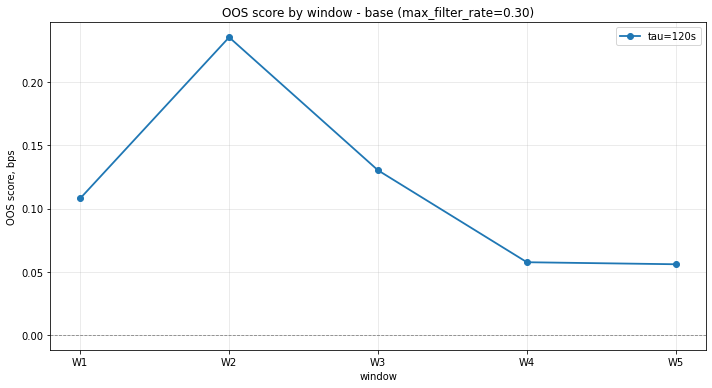

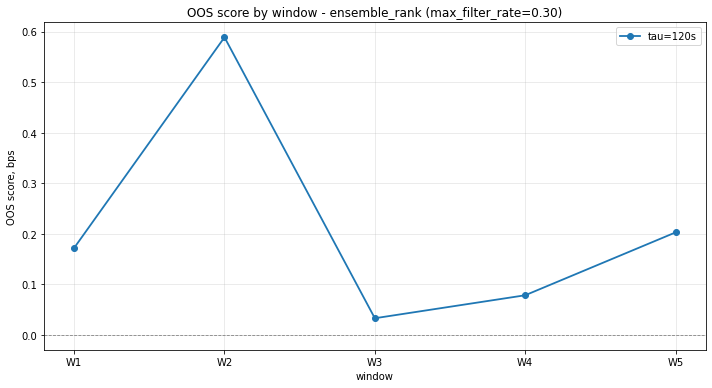

In [8]:
for variant in ("base", "ensemble_rank"):
    util.plot_score_by_window_one_chart(
        summary_030, variant=variant, taus=(TAU,),
        title=f"OOS score by window - {variant} (max_filter_rate=0.30)")

### Daily OOS score, production configuration

BTC_lgbm_huber_ensemble_rank_ensemble_rank_tau120s_fr0.3
Daily Score:
  mean   = +0.205075
  std    = 0.627382
  t-stat = +3.49  (mean / sem, 114 days)
  median = +0.168919
  min    = -1.279267
  max    = +4.059133
  >0 days: 79/114 (69%)
  <0 days: 35/114 (31%)

BTC_lgbm_huber_ensemble_rank_ensemble_rank_tau120s_fr0.3
Daily PnL kept:
  mean   = +0.162461
  std    = 0.865032
  t-stat = +2.01  (mean / sem, 114 days)
  median = +0.170875
  min    = -1.877586
  max    = +5.168396
  >0 days: 66/114 (58%)
  <0 days: 48/114 (42%)



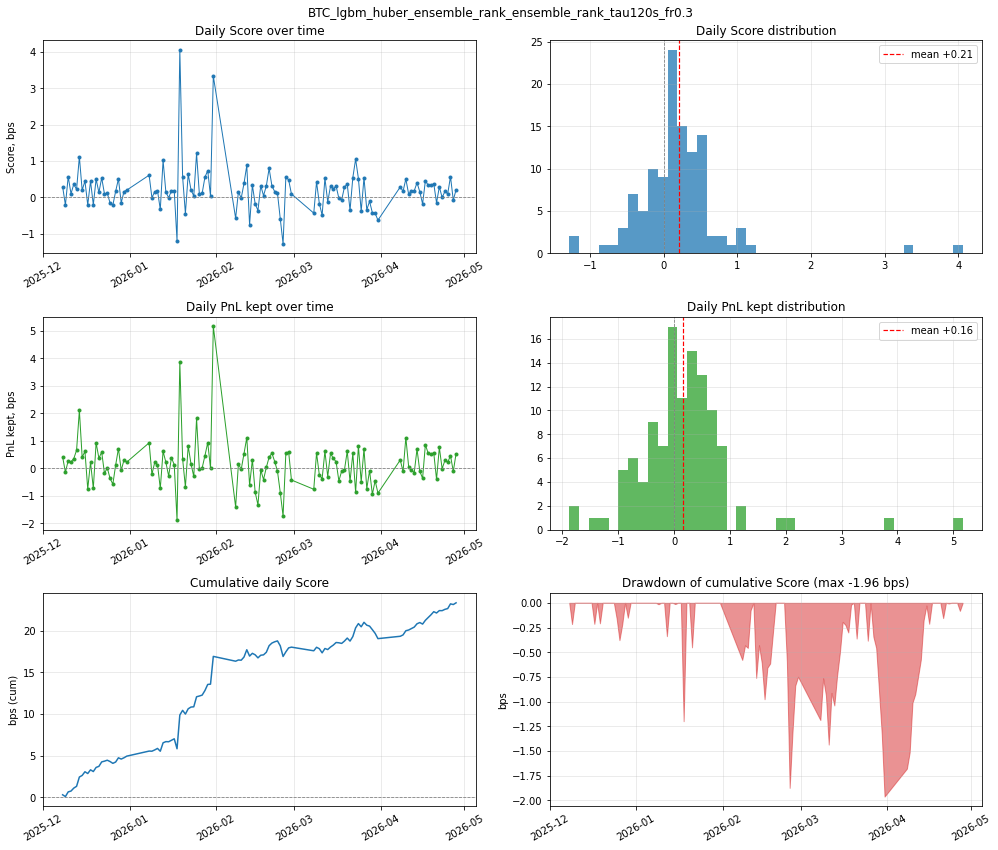

In [9]:
daily = util.plot_daily_score_distribution(
    results, variant="ensemble_rank", tau=TAU, max_filter_rate=0.30,
    instrument=INSTRUMENT, model_name="lgbm_huber_ensemble_rank")

### Paired comparison: production vs base

BTC lgbm tau=120s fr=0.3
Paired daily score, 114 common days:
  base                     mean = +0.103502
  ensemble_rank            mean = +0.205075
  diff (B - A)             mean = +0.101572
  paired t-stat = +2.29, B wins 70/114 days (61%)



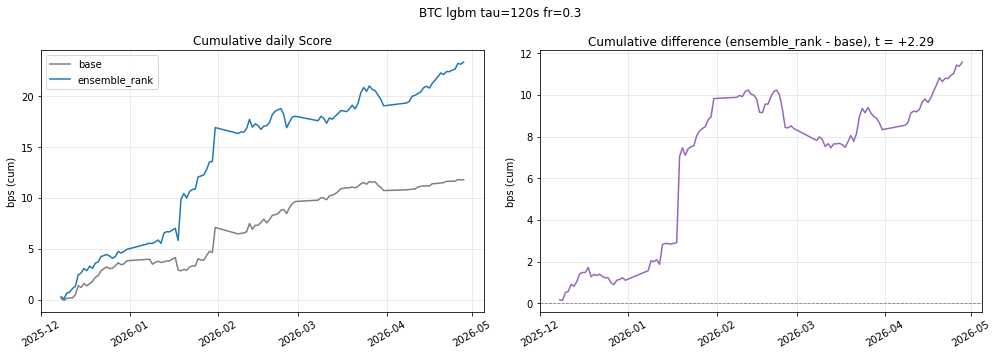

In [10]:
paired = util.compare_variants_daily(
    results, "base", "ensemble_rank", tau=TAU, max_filter_rate=0.30,
    instrument=INSTRUMENT, model_name="lgbm")

### Feature importance (production model, mean over windows)

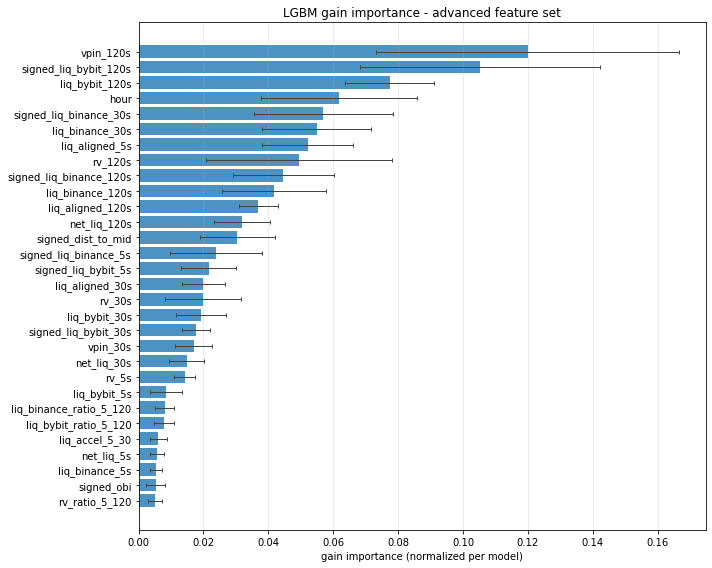

,feature,mean_importance,std_importance,n_models,sem_importance,interval
6,vpin_120s,0.119894,0.046578,20,0.010415,0.046578
28,signed_liq_bybit_120s,0.105339,0.036940,20,0.008260,0.036940
15,liq_bybit_120s,0.077379,0.013647,20,0.003051,0.013647
3,hour,0.061886,0.024055,20,0.005379,0.024055
24,signed_liq_binance_30s,0.056992,0.021493,20,0.004806,0.021493
11,liq_binance_30s,0.054861,0.016807,20,0.003758,0.016807
35,liq_aligned_5s,0.052092,0.014008,20,0.003132,0.014008
9,rv_120s,0.049451,0.028649,20,0.006406,0.028649
25,signed_liq_binance_120s,0.044607,0.015619,20,0.003493,0.015619
12,liq_binance_120s,0.041696,0.015963,20,0.003569,0.015963


In [11]:
fi = util.plot_lgbm_feature_importance(
    result_prod.models, top_n=30,
    title="LGBM gain importance - advanced feature set")
fi.head(15)

## 4. Pilot 6: feature sets across markout horizons (offline run)

`pilot6.py` compares two feature sets at tau = 30 / 120 / 300 s. Model and scoring are the same as the production run above: 4x LGBM-Huber ensemble with rank aggregation, exact threshold tuning on calib, windows W1-W5.

| variant | features | vs production |
|---------|----------|---------------|
| `advanced` | 40 | the production set: rolling windows up to 120s + signed / relative / liq-battery derived |
| `extended` | 63 | + 300s rolling (`vpin_300s`, `rv_300s`, `liq_*_300s`), mid-price momentum at 30/120/300s, 30-vs-300s ratios |

A note on tau. The dataset carries `pnl_30s / pnl_120s / pnl_300s`, but tau is part of the objective, not a tuning knob: each tau is a different target and a different score, so numbers are only comparable within a tau, never across. The main backtest runs tau = 120s because that is the horizon the task defines the score on; the sweep here checks how the filter transfers to faster and slower markouts and which feature windows each horizon actually needs.

Mean OOS score over W1-W5 (bps), run of 2026-07-14:

| config | fr <= 0.10 | fr <= 0.30 | windows > 0 (0.1 / 0.3) |
|--------|-----------:|-----------:|:-----------------------:|
| advanced, tau=120 (production) | +0.103 | +0.200 | 5/5, 5/5 |
| extended, tau=120 | +0.063 | +0.190 | 4/5, 5/5 |
| extended, tau=300 | +0.107 | +0.161 | 4/5, 4/5 |
| advanced, tau=300 | +0.062 | +0.078 | 4/5, 4/5 |
| extended, tau=30 | +0.016 | +0.075 | 4/5, 5/5 |
| advanced, tau=30 | +0.019 | +0.074 | 4/5, 4/5 |

What the numbers say (details in the tables and plots below):

- tau=120: advanced stays the champion. It is the only config positive in all five windows at both budgets. The 23 extra columns hurt here: paired per-window delta -0.040 at fr=0.1, and W1 flips from +0.066 to -0.099 -- on the shortest training window the wider set overfits.
- tau=300: the extended set wins by a wide margin (+0.084 at fr=0.3), i.e. a 300s markout wants >=300s lookbacks. Feature windows should match the horizon. Not deployable as is, though: worst window -0.146, daily t around 1.7, and the gain sits in W2/W3.
- tau=30: consistent but small. extended at fr=0.3 has the best per-window mean/std of the whole grid (1.69) and daily t = +3.70, with a mean of only +0.075. The smallest rolling window (5s) and momentum window (30s) are probably too slow for a 30s horizon.
- W1 / tau=300 is degenerate in both variants: every ensemble member early-stops at 1 iteration, so the 300s target is unlearnable on the shortest train slice. Those two cells are noise.

Artifacts, written by `pilot6.py` into `artifacts/pilot/`: `pilot6_results.parquet` (per-window scores) and `pilot6_oos.npz` + `pilot6_oos_meta.parquet` (concatenated OOS trade arrays for the daily plots; only the latest script version writes these -- re-run the pilot if they are absent).

In [ ]:
PILOT_DIR = Path("artifacts/pilot")
PILOT6_RESULTS = PILOT_DIR / "pilot6_results.parquet"
PILOT6_OOS = PILOT_DIR / "pilot6_oos.npz"
PILOT6_OOS_META = PILOT_DIR / "pilot6_oos_meta.parquet"

if not PILOT6_RESULTS.exists():
    raise FileNotFoundError(
        f"{PILOT6_RESULTS} not found — run: python3 pilot6.py"
    )

pilot6 = util.load_pilot_results(PILOT6_RESULTS)
pilot6.head()

,variant,tau,window,max_filter_rate,test_score,test_fr
0,advanced,30,W1,0.1,0.047972,0.0849
1,advanced,30,W1,0.3,0.073273,0.2003
2,advanced,120,W1,0.1,0.066395,0.1045
3,advanced,120,W1,0.3,0.162584,0.2962
4,advanced,300,W1,0.1,0.053070,0.0826


,variant,tau,max_filter_rate,mean_score,worst_window_score,std_score,mean_filter_rate,n_windows
0,advanced,30,0.1,0.019440,-0.047481,0.046344,0.03780,5
6,extended,30,0.1,0.016189,-0.041967,0.040940,0.06464,5
2,advanced,120,0.1,0.102761,0.019605,0.111755,0.08708,5
8,extended,120,0.1,0.062786,-0.098789,0.105462,0.04718,5
4,advanced,300,0.1,0.062216,-0.066778,0.102218,0.07080,5
10,extended,300,0.1,0.106872,-0.067988,0.148997,0.07872,5
1,advanced,30,0.3,0.073638,-0.001351,0.054241,0.28014,5
7,extended,30,0.3,0.075309,0.002674,0.044463,0.29868,5
3,advanced,120,0.3,0.200011,0.040887,0.221624,0.21788,5
9,extended,120,0.3,0.190098,0.019749,0.132856,0.29934,5


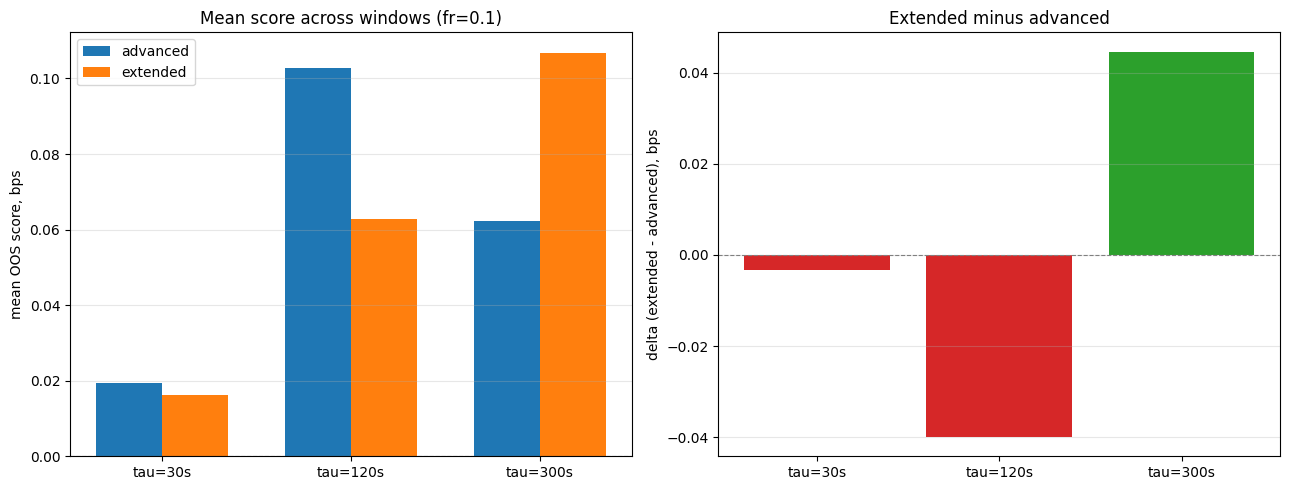

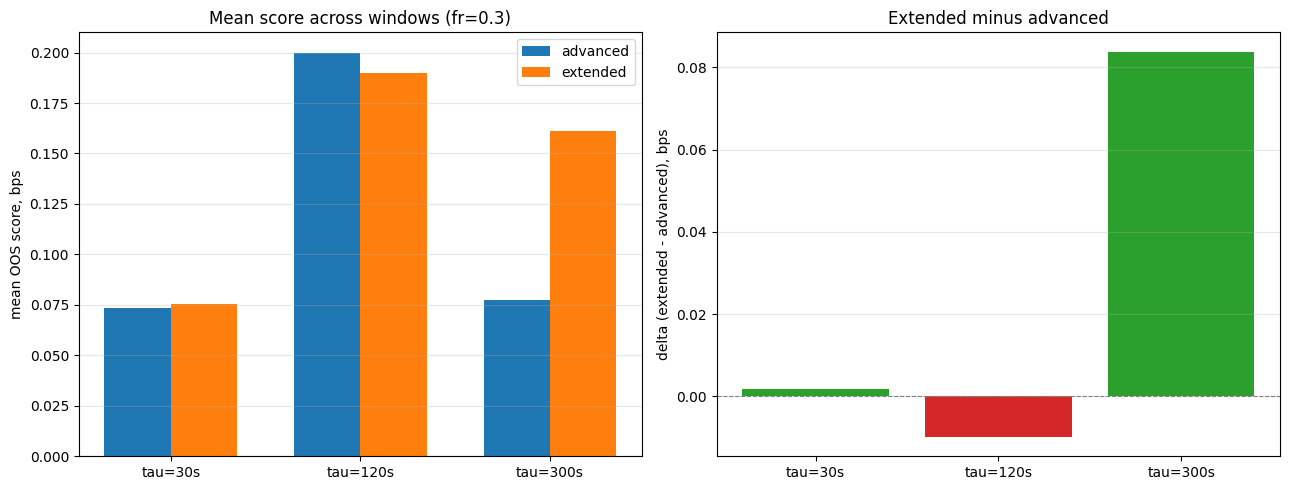

In [ ]:
# Mean score across windows + advanced vs extended delta
p6_summary = util.pilot_aggregate_summary(pilot6)
display(p6_summary.sort_values(["max_filter_rate", "tau", "variant"]))

for max_fr in (0.10, 0.30):
    util.plot_pilot_variant_comparison(pilot6, max_filter_rate=max_fr)

In [4]:
consistency = util.pilot_consistency_table(pilot6)
display(consistency)

paired_delta = util.pilot_paired_delta_table(pilot6, "advanced", "extended")
display(paired_delta)

,variant,tau,max_filter_rate,mean_score,std_score,worst_window,pos_windows,n_windows,mean_filter_rate,mean_over_std
0,advanced,30,0.1,0.019440,0.046344,-0.047481,4,5,0.03780,0.419473
1,extended,30,0.1,0.016189,0.040940,-0.041967,4,5,0.06464,0.395424
2,advanced,120,0.1,0.102761,0.111755,0.019605,5,5,0.08708,0.919521
3,extended,120,0.1,0.062786,0.105462,-0.098789,4,5,0.04718,0.595338
4,advanced,300,0.1,0.062216,0.102218,-0.066778,4,5,0.07080,0.608664
5,extended,300,0.1,0.106872,0.148997,-0.067988,4,5,0.07872,0.717277
6,advanced,30,0.3,0.073638,0.054241,-0.001351,4,5,0.28014,1.357608
7,extended,30,0.3,0.075309,0.044463,0.002674,5,5,0.29868,1.693730
8,advanced,120,0.3,0.200011,0.221624,0.040887,5,5,0.21788,0.902477
9,extended,120,0.3,0.190098,0.132856,0.019749,5,5,0.29934,1.430860


,tau,max_filter_rate,mean_delta,worst_delta,b_wins,n_windows
0,30,0.1,-0.003251,-0.025122,3,5
1,120,0.1,-0.039975,-0.165184,2,5
2,300,0.1,0.044656,-0.121058,3,5
3,30,0.3,0.001671,-0.023196,2,5
4,120,0.3,-0.009913,-0.260386,2,5
5,300,0.3,0.083834,-0.199318,3,5


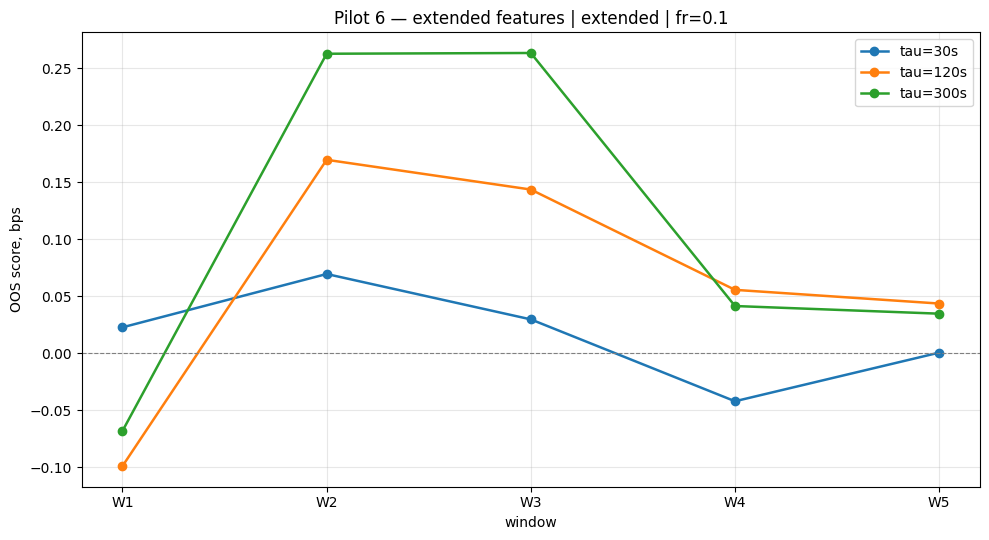

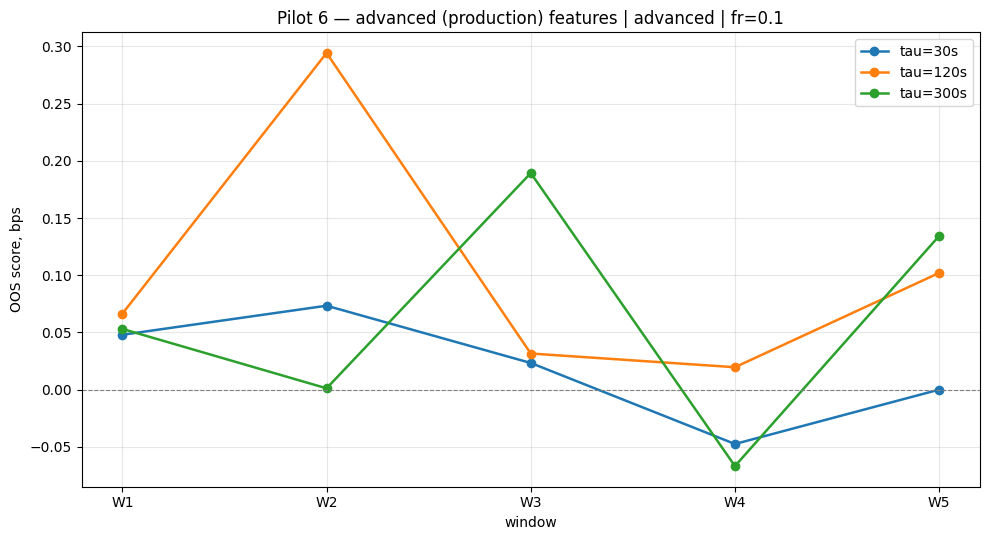

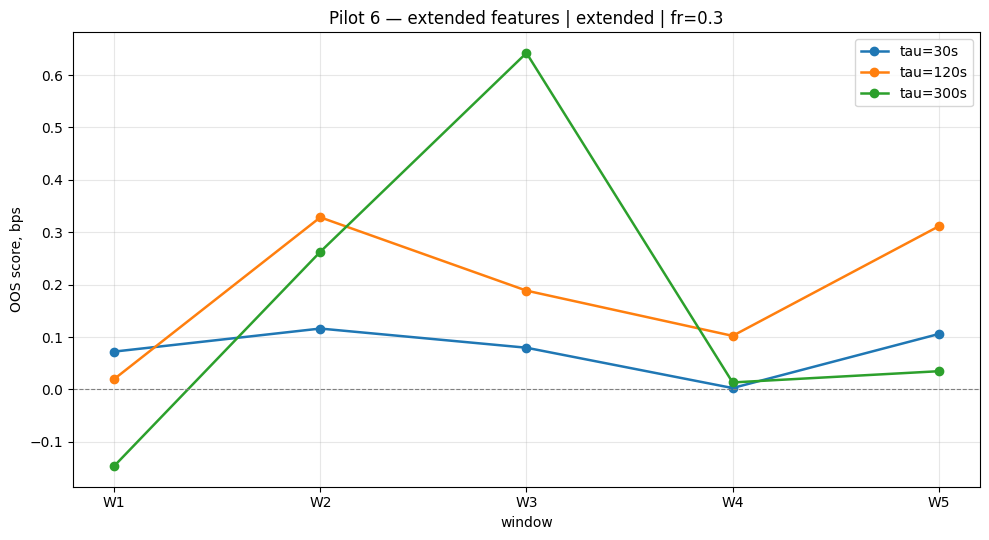

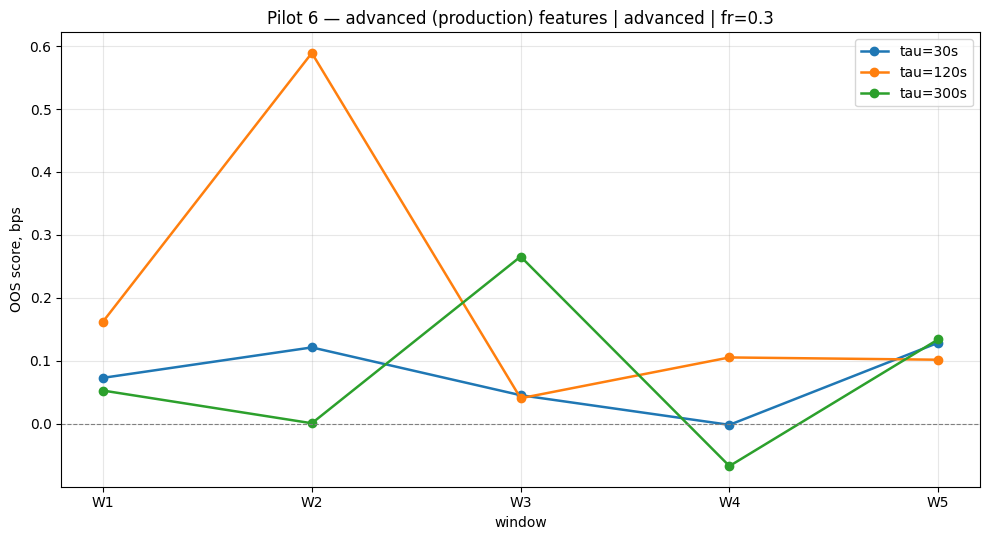

In [5]:

for max_fr in (0.10, 0.30):
    util.plot_pilot_score_by_window(
        pilot6, variant="extended", max_filter_rate=max_fr,
        title="Pilot 6 — extended features",
    )
    util.plot_pilot_score_by_window(
        pilot6, variant="advanced", max_filter_rate=max_fr,
        title="Pilot 6 — advanced (production) features",
    )

In [6]:

if PILOT6_OOS.exists() and PILOT6_OOS_META.exists():
    util.plot_pilot_daily_score(
        PILOT6_OOS, PILOT6_OOS_META,
        variant="extended", tau=120, max_filter_rate=0.30,
    )
else:
    print("Daily plots need pilot6_oos.npz — re-run pilot6.py to regenerate it.")

Daily plots need pilot6_oos.npz — re-run pilot6.py to regenerate it.


### 4b. Pilot 7: horizon-matched feature blocks (v2 dataset)

Pilot 6 suggested that feature windows should match the markout horizon; pilot 7 tests that directly. The dataset was rebuilt with extra rolling and momentum windows (the BUILD_DATASET cell above now produces the full window set; same 20.1M rows, ~90 min), and every challenger is the production `advanced` set plus one focused block -- so a win or a loss attributes to that block alone. Model and scoring unchanged: 4x LGBM-Huber, rank aggregation, exact threshold tuning, W1-W5.

What is new in the v2 dataset (21 raw columns, computed on the full trade stream at build time):

| block | columns | windows |
|-------|---------|---------|
| fast rolling | `vpin_{w}s`, `rv_{w}s`, `liq_binance_{w}s`, `liq_bybit_{w}s` | 1s, 10s |
| slow rolling | same four | 600s |
| fast momentum | `mid_ret_{w}s`, `signed_mid_ret_{w}s`, `abs_mid_ret_{w}s` | 5s, 10s |
| slow momentum | same three | 600s |

Derived on the fly in `add_all_derived_features` (`src/features.py`):

- fast (7): `signed_liq_binance_1s/10s`, `signed_liq_bybit_1s/10s`, `liq_accel_1_30`, `vpin_ratio_1_30`, `rv_ratio_1_30`
- slow (5): `signed_liq_binance_600s`, `signed_liq_bybit_600s`, `net_liq_600s`, `vpin_ratio_120_600`, `rv_ratio_120_600`
- the 300s block from pilot 6 (10): `net_liq_300s`, `signed_liq_*_300s`, `liq_aligned_300s`, `liq_direction_agreement_300s`, `liq_accel_30_300`, `vpin_ratio_30_300`, `rv_ratio_30_300`, `liq_*_ratio_30_300`

The grid -- production control plus one block per horizon:

| tau | config | feats | added on top of advanced (40) |
|-----|--------|------:|-------------------------------|
| 30  | `fast30` | 64 | 1s/10s rolling + their signed versions, 1-vs-30s ratios, 5/10/30s momentum |
| 120 | `adv_momentum` | 49 | 30/120/300s momentum only |
| 300 | `adv_momentum` | 49 | same set, trained on the 300s target |
| 300 | `roll300` | 54 | 300s rolling + 300s derived, no momentum |
| 300 | `slow300` | 72 | roll300 + 600s rolling + 120/300/600s momentum + 600s derived |

Mean OOS score over W1-W5 (bps), daily t on the 114 pooled OOS days, run of 2026-07-15:

| tau | config | fr <= 0.1 | fr <= 0.3 | windows > 0 @ 0.3 | daily t @ 0.3 |
|-----|--------|----------:|----------:|:-----------------:|--------------:|
| 30  | advanced (control) | +0.021 | +0.075 | 4/5 | +4.01 |
| 30  | fast30 | +0.022 | +0.091 | 4/5 | +4.09 |
| 120 | advanced (control, production) | +0.104 | +0.190 | 5/5 | +3.30 |
| 120 | adv_momentum | +0.076 | +0.135 | 4/5 | +3.41 |
| 300 | advanced (control) | +0.065 | +0.117 | 4/5 | +1.35 |
| 300 | adv_momentum | +0.175 | +0.277 | 4/5 | +2.63 |
| 300 | roll300 | +0.151 | +0.258 | 5/5 | +3.07 |
| 300 | slow300 | +0.189 | +0.279 | 5/5 | +3.08 |

What came out of it:

- tau=300 is where the new features pay. All three challengers beat the control by +0.14..0.16 bps at fr=0.3 (paired daily t up to +2.9), and the tau=300 filter goes from "unstable, t=1.35" to a deployable config: roll300 is positive in all five windows at fr=0.3 with worst window +0.118 and t=3.07; slow300 is positive in all five windows at both budgets. Versus pilot 6's extended (+0.161) the score roughly x1.7 on the same target.
- momentum and 300s rolling are interchangeable at tau=300. Pairwise paired-t between adv_momentum / roll300 / slow300 is 0.0-0.7 -- they encode the same slow signal. Stacking both (slow300) adds nothing significant over roll300 alone, so the lean pick is roll300: 54 features, and 61% of its gain sits in the new block (`signed_liq_bybit_300s` alone takes 17%).
- tau=120: the pilot-6 attribution question is answered -- momentum is what hurt. adv_momentum loses to the control at both budgets (-0.028 / -0.056) while the model happily assigns the momentum columns 29% of gain importance. Importance is not OOS value; at 120s momentum is an overfitting magnet. Production config stays exactly as is.
- tau=30: a small real gain at fr=0.3 (+0.075 -> +0.091, paired daily t +2.22, best daily t of the grid at +4.09), nothing at fr=0.1. The 1s columns barely register in the importance table; what works is `signed_mid_ret_30s` and `signed_liq_binance_10s`. The 30s horizon stays a low-magnitude story.
- caveat: W1 / tau=300 is still degenerate -- every member of every config early-stops at 1 iteration (the target is unlearnable on the shortest train slice), so W1 scores at tau=300 come from single-tree models. The tau=300 conclusions rest on W2-W5. And as before: the same five windows have served many comparisons; ETH confirmation is due before promoting anything.

Runtime, for the record: dataset rebuild 88 min, full grid (8 configs x 5 windows x 4 members) 3h08m on 12 cores.

Artifacts in `artifacts/pilot/`: `btc_pilot7_{results,oos,oos_meta,importance}.*` plus `btc_pilot7.log`; produced by `pilot7.py`.

In [7]:
PILOT7_RESULTS = PILOT_DIR / "btc_pilot7_results.parquet"
PILOT7_OOS = PILOT_DIR / "btc_pilot7_oos.npz"
PILOT7_OOS_META = PILOT_DIR / "btc_pilot7_oos_meta.parquet"
PILOT7_IMPORTANCE = PILOT_DIR / "btc_pilot7_importance.npz"

pilot7 = util.load_pilot_results(PILOT7_RESULTS)
util.pilot_consistency_table(pilot7)

,variant,tau,max_filter_rate,mean_score,std_score,worst_window,pos_windows,n_windows,mean_filter_rate,mean_over_std
0,advanced,30,0.1,0.020741,0.048403,-0.046699,4,5,0.03932,0.428501
1,fast30,30,0.1,0.021940,0.050182,-0.055521,3,5,0.06430,0.437205
2,adv_momentum,120,0.1,0.075987,0.128594,-0.069868,3,5,0.05970,0.590911
3,advanced,120,0.1,0.104271,0.110201,0.028208,5,5,0.08694,0.946187
4,adv_momentum,300,0.1,0.174540,0.126409,-0.017447,4,5,0.07346,1.380755
5,advanced,300,0.1,0.065346,0.110512,-0.076748,4,5,0.06608,0.591306
6,roll300,300,0.1,0.150505,0.120318,-0.043489,4,5,0.06284,1.250886
7,slow300,300,0.1,0.188524,0.152957,0.033914,5,5,0.07618,1.232532
8,advanced,30,0.3,0.074949,0.055301,-0.000644,4,5,0.28124,1.355307
9,fast30,30,0.3,0.091281,0.064937,-0.022746,4,5,0.29714,1.405689


In [8]:
util.pilot_paired_daily_table(
    PILOT7_OOS, PILOT7_OOS_META,
    pairs=[
        ("fast30", "advanced", 30),
        ("adv_momentum", "advanced", 120),
        ("adv_momentum", "advanced", 300),
        ("roll300", "advanced", 300),
        ("slow300", "advanced", 300),
        ("slow300", "roll300", 300),
    ],
)

,challenger,control,tau,max_filter_rate,mean_daily_diff,paired_t,share_days_ahead,n_days
0,fast30,advanced,30,0.1,0.003026,0.573083,0.464912,114
1,fast30,advanced,30,0.3,0.017642,2.223672,0.596491,114
2,adv_momentum,advanced,120,0.1,-0.031740,-1.311339,0.438596,114
3,adv_momentum,advanced,120,0.3,-0.045840,-1.076973,0.473684,114
4,adv_momentum,advanced,300,0.1,0.093820,1.926156,0.552632,114
5,adv_momentum,advanced,300,0.3,0.157416,2.941350,0.596491,114
6,roll300,advanced,300,0.1,0.093340,1.634438,0.500000,114
7,roll300,advanced,300,0.3,0.157555,2.891405,0.587719,114
8,slow300,advanced,300,0.1,0.124694,1.682047,0.517544,114
9,slow300,advanced,300,0.3,0.158401,2.197083,0.561404,114


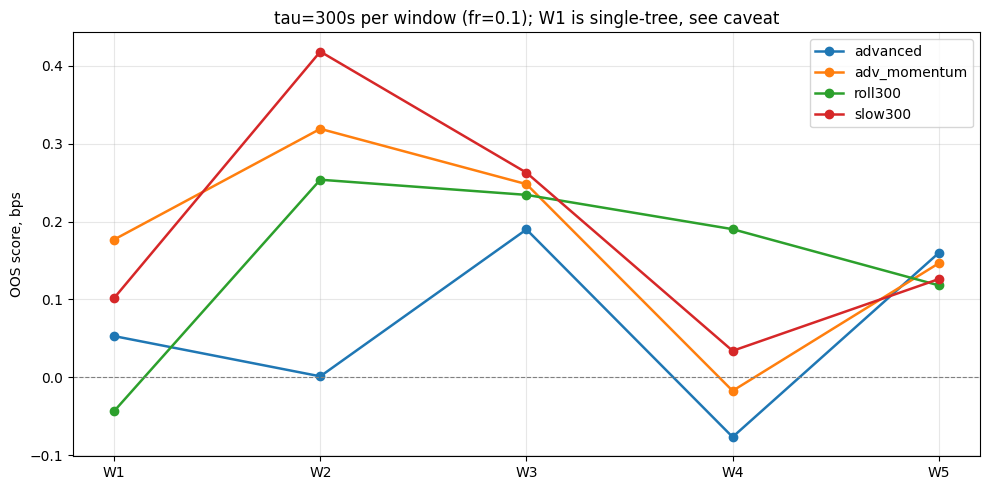

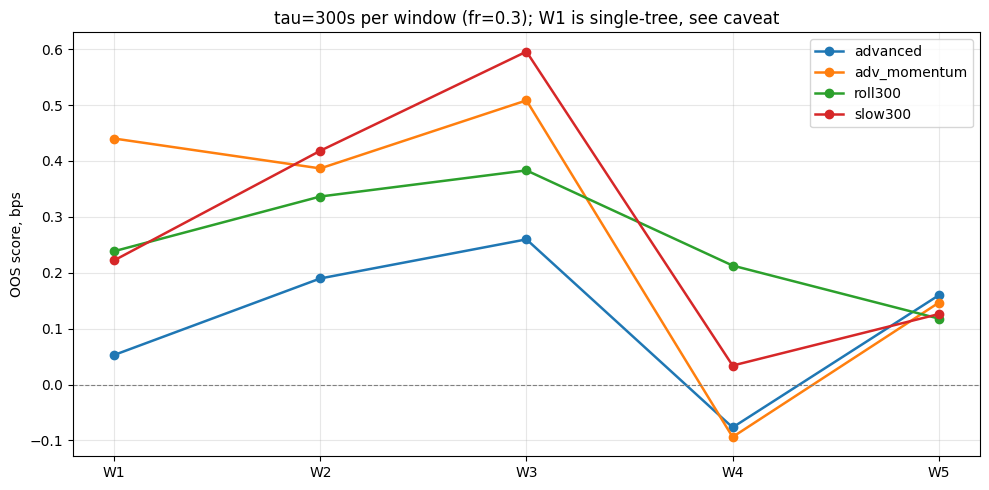

In [9]:
import matplotlib.pyplot as plt

for max_fr in (0.10, 0.30):
    sub = pilot7[(pilot7["tau"] == 300) & np.isclose(pilot7["max_filter_rate"], max_fr)]
    pv = sub.pivot_table(index="window", columns="variant", values="test_score")
    pv = pv[["advanced", "adv_momentum", "roll300", "slow300"]]

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(pv.index))
    for name in pv.columns:
        ax.plot(x, pv[name].values, "o-", lw=1.8, ms=6, label=name)
    ax.axhline(0, color="gray", lw=0.8, ls="--")
    ax.set_xticks(x); ax.set_xticklabels(pv.index)
    ax.set_ylabel("OOS score, bps")
    ax.set_title(f"tau=300s per window (fr={max_fr}); W1 is single-tree, see caveat")
    ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()

BTC_pilot7_ens_rank_roll300_tau300s_fr0.3
Daily Score:
  mean   = +0.252449
  std    = 0.878648
  t-stat = +3.07  (mean / sem, 114 days)
  median = +0.179457
  min    = -1.742478
  max    = +3.334071
  >0 days: 80/114 (70%)
  <0 days: 34/114 (30%)

BTC_pilot7_ens_rank_roll300_tau300s_fr0.3
Daily PnL kept:
  mean   = +0.264573
  std    = 1.190959
  t-stat = +2.37  (mean / sem, 114 days)
  median = +0.306231
  min    = -3.600744
  max    = +4.698832
  >0 days: 74/114 (65%)
  <0 days: 40/114 (35%)



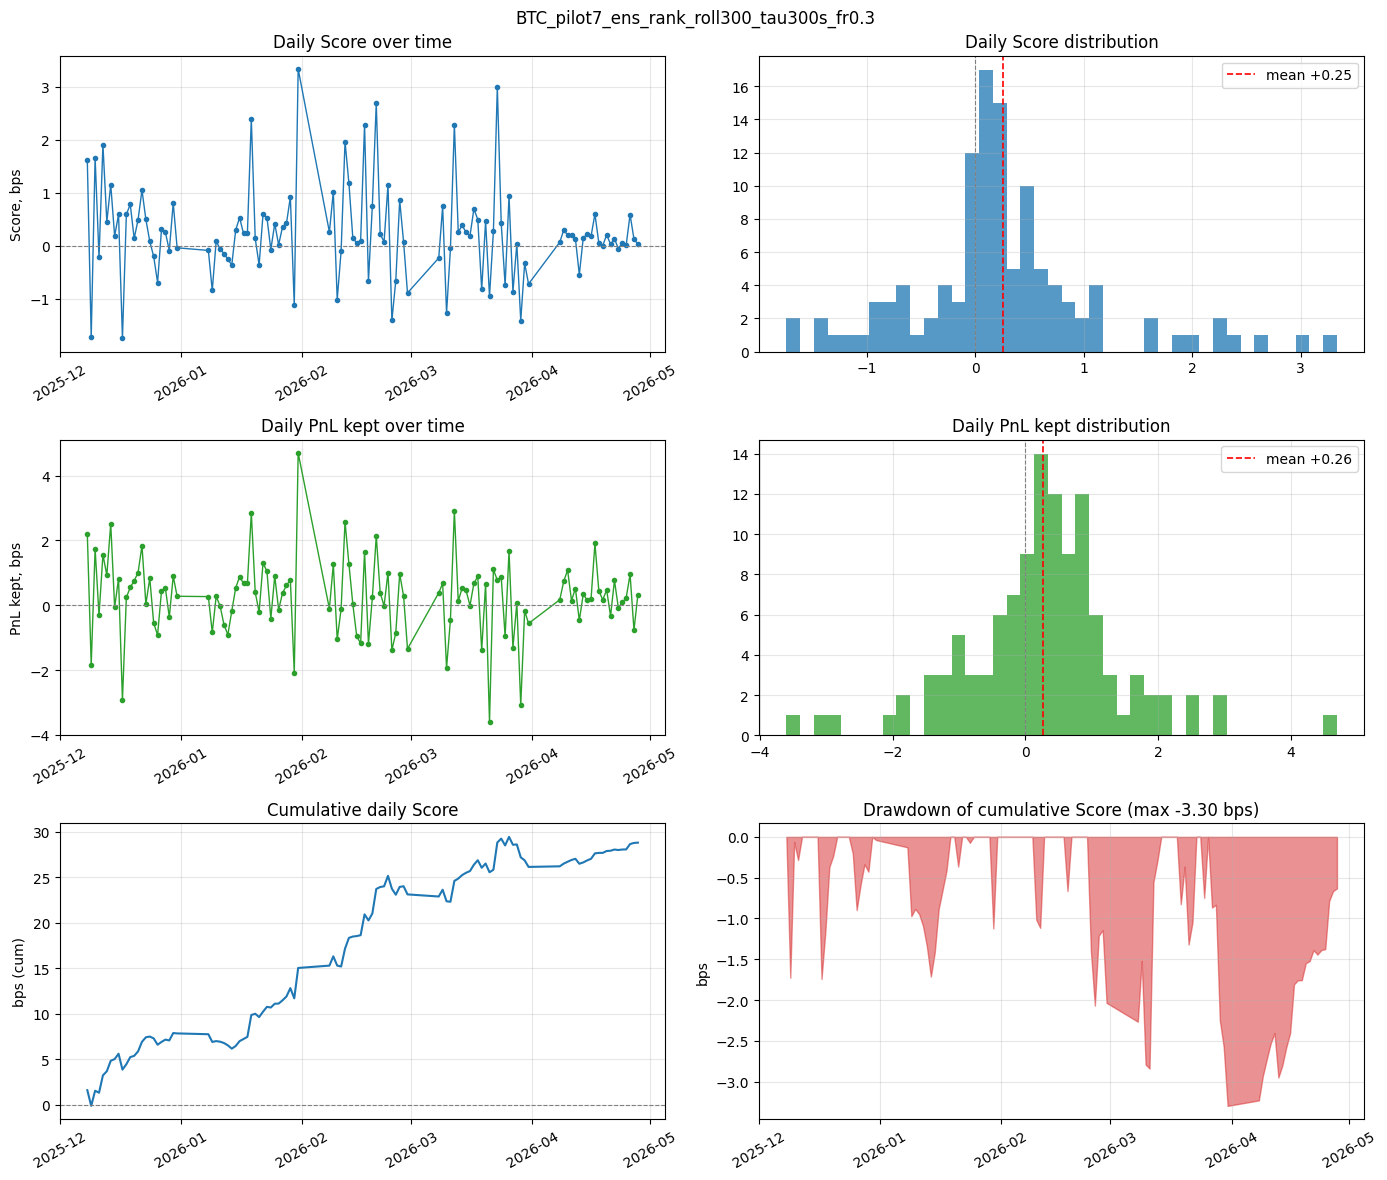

BTC_pilot7_ens_rank_fast30_tau30s_fr0.3
Daily Score:
  mean   = +0.100633
  std    = 0.262714
  t-stat = +4.09  (mean / sem, 114 days)
  median = +0.125814
  min    = -1.838814
  max    = +0.659115
  >0 days: 90/114 (79%)
  <0 days: 24/114 (21%)

BTC_pilot7_ens_rank_fast30_tau30s_fr0.3
Daily PnL kept:
  mean   = +0.006995
  std    = 0.458777
  t-stat = +0.16  (mean / sem, 114 days)
  median = +0.074997
  min    = -3.156993
  max    = +0.925321
  >0 days: 66/114 (58%)
  <0 days: 48/114 (42%)



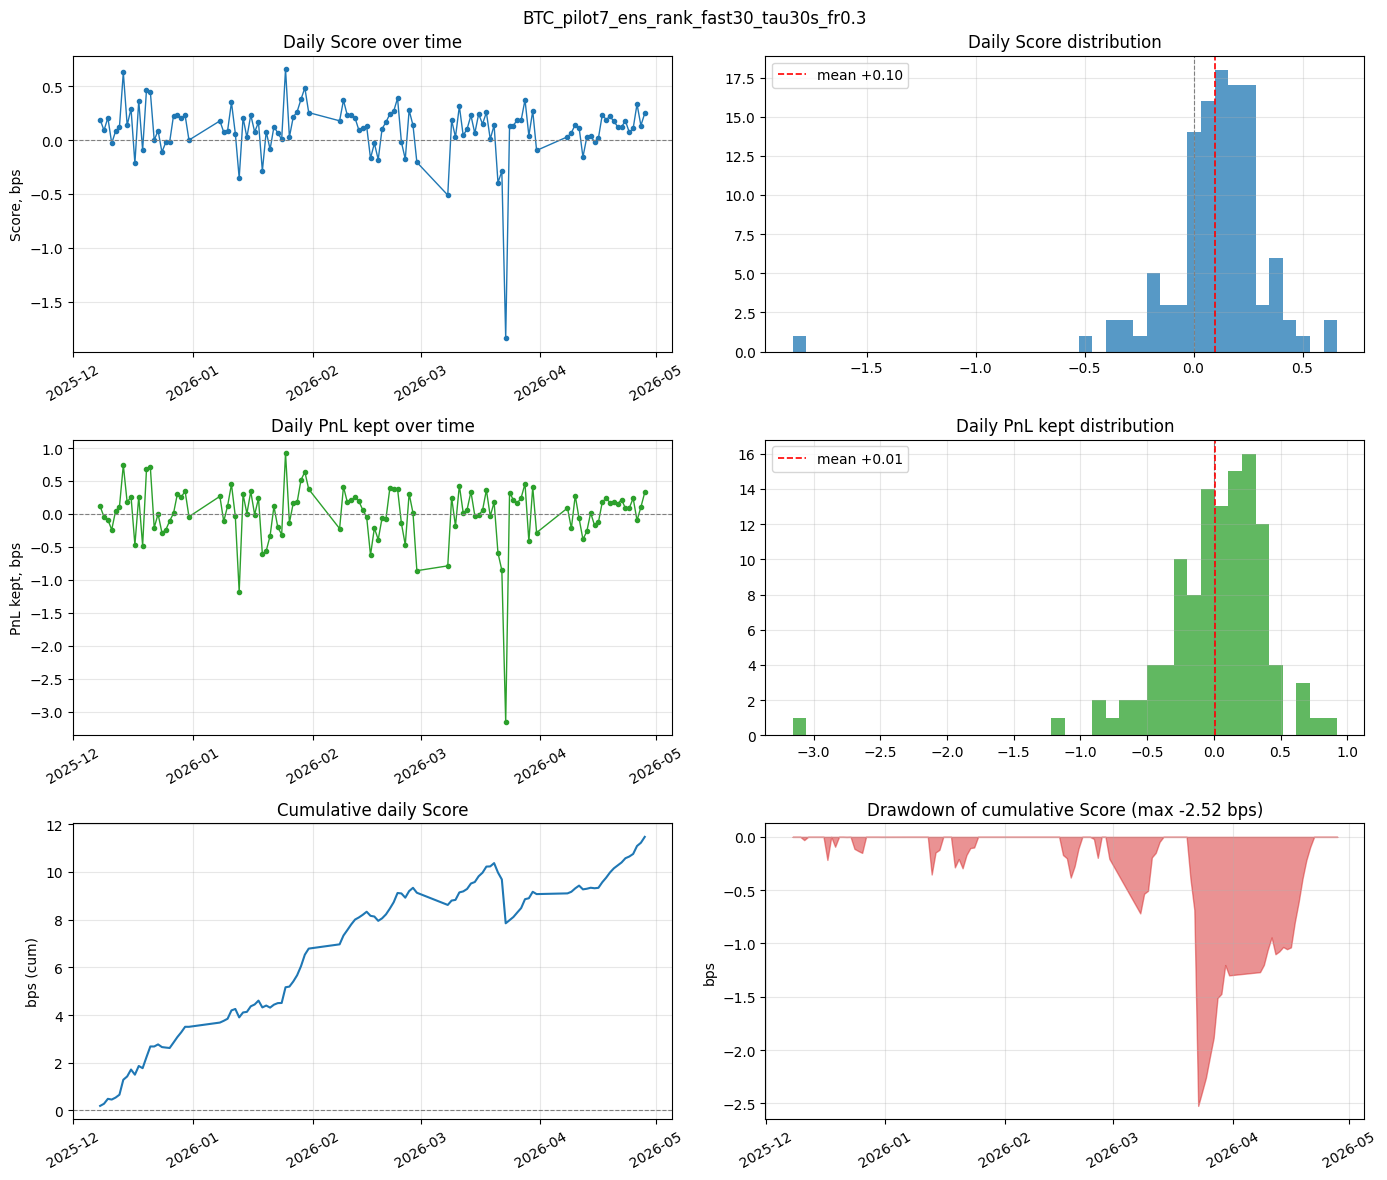

,day,daily_score,daily_pnl_kept
0,2025-12-08,0.189987,0.114943
1,2025-12-09,0.089300,-0.044628
2,2025-12-10,0.206827,-0.088591
3,2025-12-11,-0.030154,-0.239902
4,2025-12-12,0.082028,0.044977
...,...,...,...
109,2026-04-24,0.070958,0.090936
110,2026-04-25,0.108343,0.237785
111,2026-04-26,0.333488,-0.098574
112,2026-04-27,0.134890,0.102959


In [10]:

util.plot_pilot_daily_score(
    PILOT7_OOS, PILOT7_OOS_META,
    variant="roll300", tau=300, max_filter_rate=0.30,
    model_name="pilot7_ens_rank",
)
util.plot_pilot_daily_score(
    PILOT7_OOS, PILOT7_OOS_META,
    variant="fast30", tau=30, max_filter_rate=0.30,
    model_name="pilot7_ens_rank",
)

In [11]:
# What the new blocks actually contribute: mean gain importance per config.
imp = np.load(PILOT7_IMPORTANCE, allow_pickle=True)
from features import get_feature_set
advanced_set = set(get_feature_set("advanced"))

for key in ("roll300|300", "slow300|300", "fast30|30", "adv_momentum|120"):
    gain = imp[f"{key}/gain"]
    feats = list(imp[f"{key}/features"])
    gain = gain / gain.sum()
    new_share = sum(g for f, g in zip(feats, gain) if f not in advanced_set)
    top = sorted(zip(feats, gain), key=lambda t: -t[1])[:10]
    print(f"{key}: new-block gain share {new_share:.0%}")
    for f, g in top:
        mark = "*" if f not in advanced_set else " "
        print(f"  {mark} {f:<28} {g:.3f}")
    print()

roll300|300: new-block gain share 61%
  * signed_liq_bybit_300s        0.174
  * liq_bybit_300s               0.098
    hour                         0.088
  * vpin_300s                    0.077
  * liq_aligned_300s             0.050
  * net_liq_300s                 0.049
  * signed_liq_binance_300s      0.049
  * rv_300s                      0.039
    liq_aligned_120s             0.035
  * liq_binance_300s             0.030

slow300|300: new-block gain share 81%
  * signed_liq_bybit_600s        0.099
  * signed_mid_ret_600s          0.093
    hour                         0.070
  * liq_binance_600s             0.064
  * liq_bybit_600s               0.062
  * signed_liq_bybit_300s        0.056
  * vpin_600s                    0.039
  * signed_mid_ret_300s          0.038
  * signed_liq_binance_300s      0.035
  * liq_bybit_300s               0.034

fast30|30: new-block gain share 25%
    signed_dist_to_mid           0.066
    signed_liq_binance_30s       0.065
    liq_aligned_5s          

### 4c. ETH confirmation run

Out-of-family check of the pilot-7 findings: same recipe end to end (`INSTRUMENT=eth python3 pilot7.py` on `data/enriched/eth_sub40.parquet`, built with the BUILD_DATASET cell pointed at the ETH raw files; ~1.6x the BTC trade count), same model, scoring and W1-W5 splits, reduced grid -- only the claims worth confirming:

| tau | configs | claim under test |
|-----|---------|------------------|
| 120 | `advanced` | the production recipe transfers to a second instrument |
| 300 | `advanced` vs `roll300` | the pilot-7 winner beats its control off-BTC |
| 30  | `advanced` vs `fast30` | the small fast-features gain is not a BTC artifact |

Results land in `eth_pilot7_{results,oos,oos_meta,importance}.*`; the cells below mirror the BTC pilot-7 analysis (consistency, paired daily tests, per-window curves, daily panels, importance). Run of 2026-07-15, 4h20m on 12 cores (`artifacts/pilot/eth_pilot7_run.log`); verdict in the summary below.

In [5]:
ETH_RESULTS = PILOT_DIR / "eth_pilot7_results.parquet"
ETH_OOS = PILOT_DIR / "eth_pilot7_oos.npz"
ETH_OOS_META = PILOT_DIR / "eth_pilot7_oos_meta.parquet"
ETH_IMPORTANCE = PILOT_DIR / "eth_pilot7_importance.npz"

eth7 = util.load_pilot_results(ETH_RESULTS)
util.pilot_consistency_table(eth7)

,variant,tau,max_filter_rate,mean_score,std_score,worst_window,pos_windows,n_windows,mean_filter_rate,mean_over_std
0,advanced,30,0.1,0.028885,0.065227,-0.068984,4,5,0.07806,0.442831
1,fast30,30,0.1,0.024977,0.058730,-0.065907,4,5,0.06094,0.425285
2,advanced,120,0.1,0.183080,0.204615,0.002275,5,5,0.06528,0.894757
3,advanced,300,0.1,0.014047,0.213953,-0.340611,4,5,0.02850,0.065656
4,roll300,300,0.1,-0.018344,0.334865,-0.585809,3,5,0.05996,-0.054779
5,advanced,30,0.3,0.076920,0.109927,-0.076965,4,5,0.22194,0.699738
6,fast30,30,0.3,0.087756,0.134426,-0.091976,4,5,0.23594,0.652818
7,advanced,120,0.3,0.304318,0.341793,0.043490,5,5,0.24126,0.890359
8,advanced,300,0.3,-0.061930,0.376834,-0.720499,4,5,0.06196,-0.164344
9,roll300,300,0.3,-0.115485,0.646329,-1.236760,3,5,0.13190,-0.178678


In [6]:
# Paired daily t-tests for the two ETH claims.
util.pilot_paired_daily_table(
    ETH_OOS, ETH_OOS_META,
    pairs=[
        ("fast30", "advanced", 30),
        ("roll300", "advanced", 300),
    ],
)

,challenger,control,tau,max_filter_rate,mean_daily_diff,paired_t,share_days_ahead,n_days
0,fast30,advanced,30,0.1,0.000032,0.002915,0.429825,114
1,fast30,advanced,30,0.3,0.007008,0.565705,0.491228,114
2,roll300,advanced,300,0.1,-0.010413,-0.208454,0.350877,114
3,roll300,advanced,300,0.3,0.006688,0.079160,0.377193,114


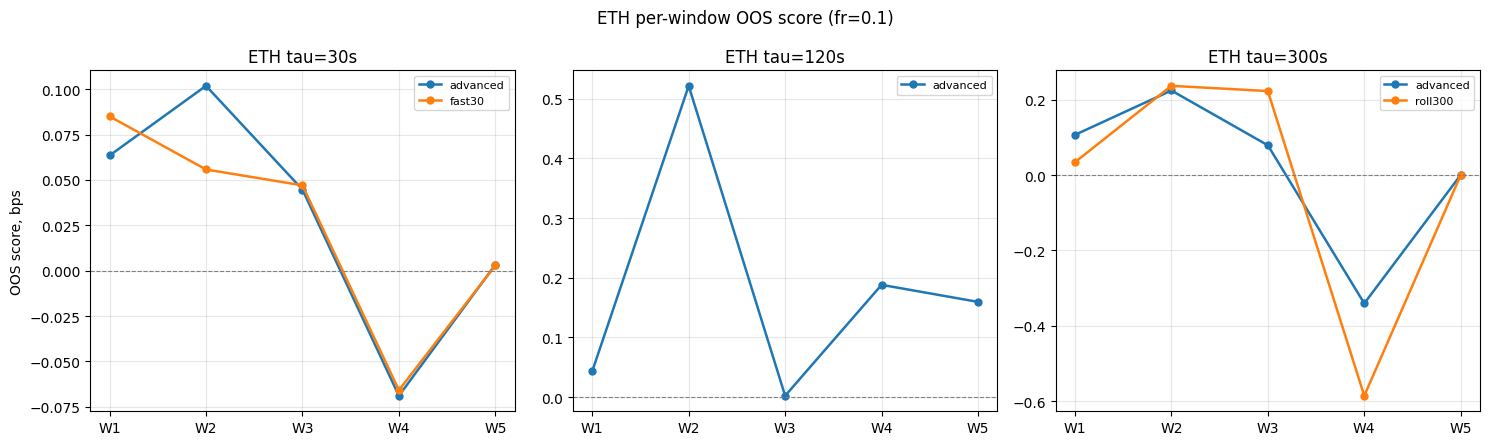

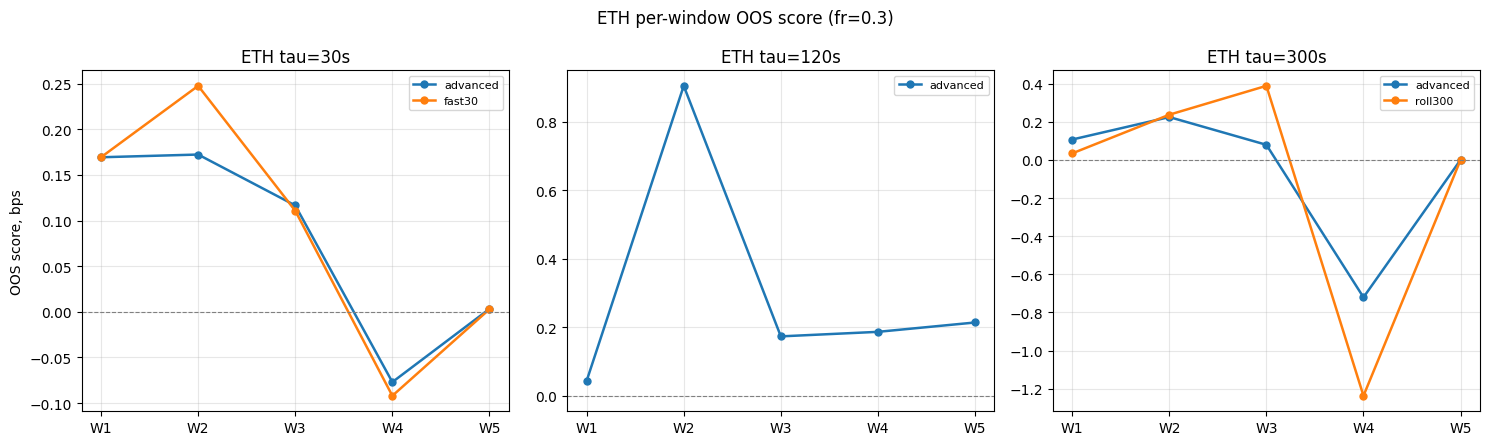

In [7]:
# Per-window curves: challenger vs control at each tau, ETH.
ETH_PAIRS = {30: ["advanced", "fast30"], 120: ["advanced"], 300: ["advanced", "roll300"]}

for max_fr in (0.10, 0.30):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)
    for ax, (tau, variants) in zip(axes, sorted(ETH_PAIRS.items())):
        sub = eth7[(eth7["tau"] == tau) & np.isclose(eth7["max_filter_rate"], max_fr)]
        pv = sub.pivot_table(index="window", columns="variant", values="test_score")
        x = np.arange(len(pv.index))
        for name in variants:
            if name in pv.columns:
                ax.plot(x, pv[name].values, "o-", lw=1.8, ms=5, label=name)
        ax.axhline(0, color="gray", lw=0.8, ls="--")
        ax.set_xticks(x); ax.set_xticklabels(pv.index)
        ax.set_title(f"ETH tau={tau}s")
        ax.grid(alpha=0.3); ax.legend(fontsize=8)
    axes[0].set_ylabel("OOS score, bps")
    fig.suptitle(f"ETH per-window OOS score (fr={max_fr})")
    plt.tight_layout(); plt.show()

ETH_eth_pilot7_ens_rank_advanced_tau120s_fr0.3
Daily Score:
  mean   = +0.236621
  std    = 1.073565
  t-stat = +2.35  (mean / sem, 114 days)
  median = +0.142645
  min    = -2.699436
  max    = +8.635169
  >0 days: 81/114 (71%)
  <0 days: 33/114 (29%)

ETH_eth_pilot7_ens_rank_advanced_tau120s_fr0.3
Daily PnL kept:
  mean   = +0.235683
  std    = 1.425496
  t-stat = +1.77  (mean / sem, 114 days)
  median = +0.164222
  min    = -3.888152
  max    = +10.694029
  >0 days: 71/114 (62%)
  <0 days: 43/114 (38%)



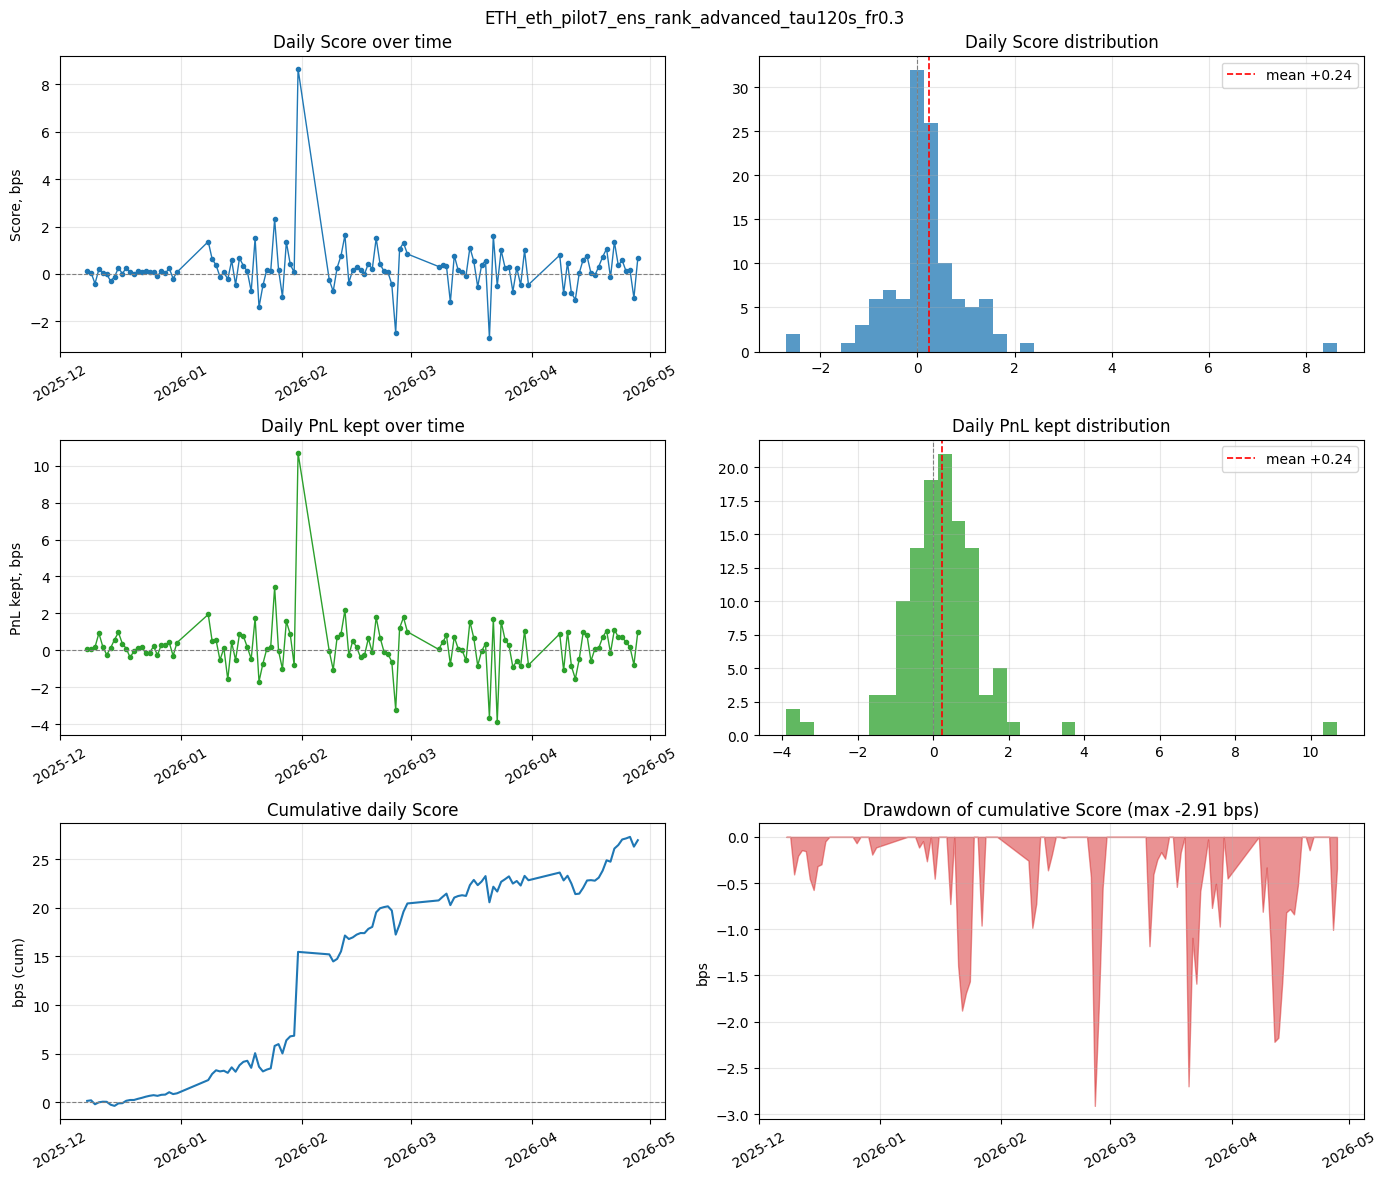

ETH_eth_pilot7_ens_rank_roll300_tau300s_fr0.3
Daily Score:
  mean   = -0.097682
  std    = 1.952362
  t-stat = -0.53  (mean / sem, 114 days)
  median = +0.000000
  min    = -13.713150
  max    = +2.969928
  >0 days: 48/114 (42%)
  <0 days: 29/114 (25%)

ETH_eth_pilot7_ens_rank_roll300_tau300s_fr0.3
Daily PnL kept:
  mean   = -0.068729
  std    = 2.773368
  t-stat = -0.26  (mean / sem, 114 days)
  median = +0.302753
  min    = -18.633253
  max    = +4.966489
  >0 days: 73/114 (64%)
  <0 days: 41/114 (36%)



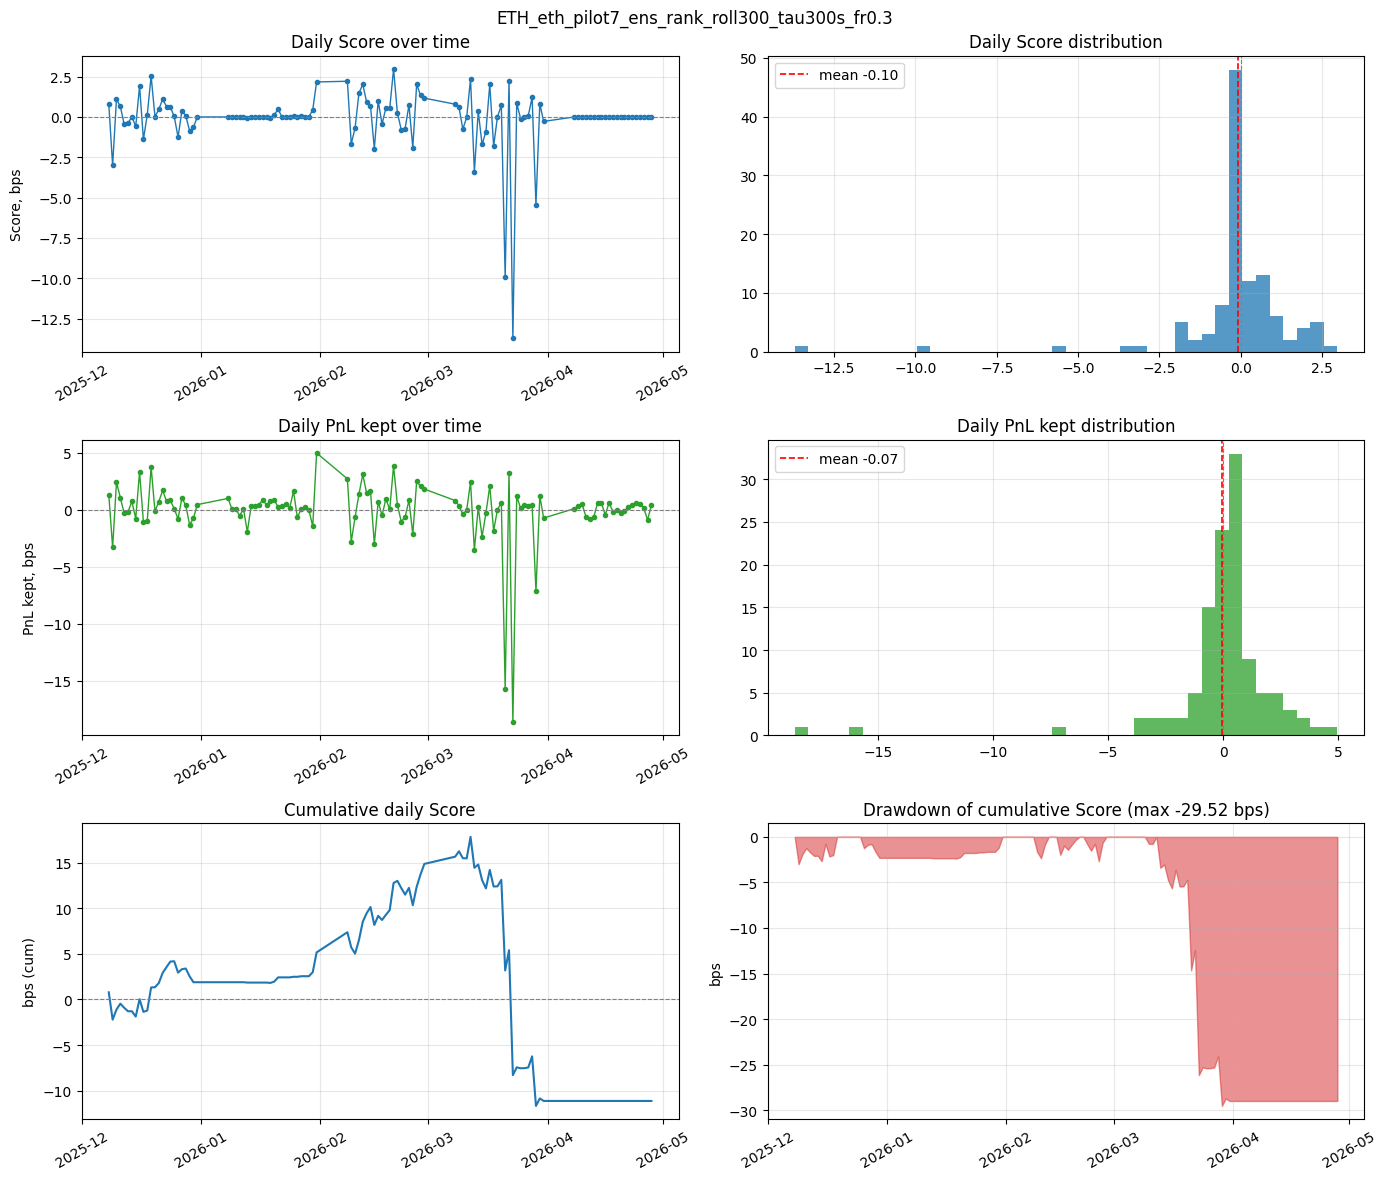

ETH_eth_pilot7_ens_rank_fast30_tau30s_fr0.3
Daily Score:
  mean   = +0.096760
  std    = 0.529710
  t-stat = +1.95  (mean / sem, 114 days)
  median = +0.108145
  min    = -3.589482
  max    = +2.150777
  >0 days: 74/114 (65%)
  <0 days: 27/114 (24%)

ETH_eth_pilot7_ens_rank_fast30_tau30s_fr0.3
Daily PnL kept:
  mean   = +0.023107
  std    = 0.787779
  t-stat = +0.31  (mean / sem, 114 days)
  median = +0.085587
  min    = -5.858724
  max    = +2.195630
  >0 days: 68/114 (60%)
  <0 days: 46/114 (40%)



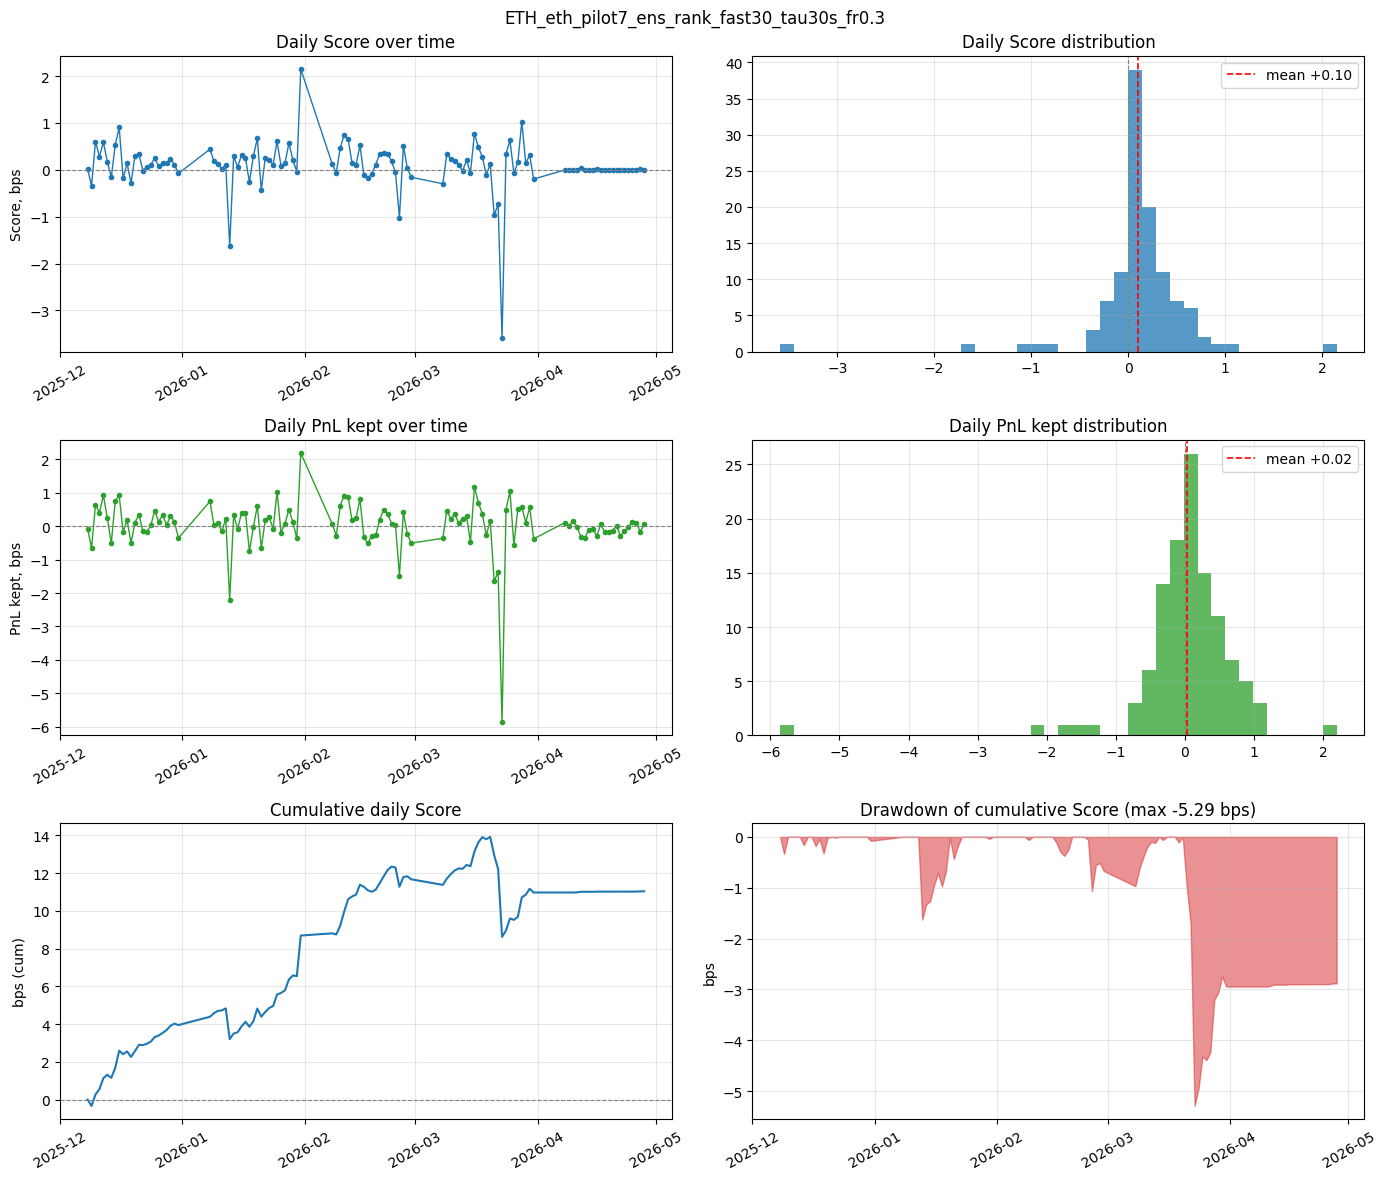

,day,daily_score,daily_pnl_kept
0,2025-12-08,0.007622,-0.074005
1,2025-12-09,-0.334077,-0.651840
2,2025-12-10,0.604280,0.651713
3,2025-12-11,0.281567,0.407657
4,2025-12-12,0.586422,0.930341
...,...,...,...
109,2026-04-24,0.000000,-0.031367
110,2026-04-25,0.000000,0.134454
111,2026-04-26,0.000000,0.109721
112,2026-04-27,0.014305,-0.159272


In [8]:
# Daily OOS panels: production recipe on ETH, then the two challengers.
util.plot_pilot_daily_score(
    ETH_OOS, ETH_OOS_META,
    variant="advanced", tau=120, max_filter_rate=0.30,
    instrument="eth", model_name="eth_pilot7_ens_rank",
)
util.plot_pilot_daily_score(
    ETH_OOS, ETH_OOS_META,
    variant="roll300", tau=300, max_filter_rate=0.30,
    instrument="eth", model_name="eth_pilot7_ens_rank",
)
util.plot_pilot_daily_score(
    ETH_OOS, ETH_OOS_META,
    variant="fast30", tau=30, max_filter_rate=0.30,
    instrument="eth", model_name="eth_pilot7_ens_rank",
)

In [9]:
# Gain importance on ETH: do the same features carry the signal as on BTC.
eth_imp = np.load(ETH_IMPORTANCE, allow_pickle=True)

for key in ("roll300|300", "fast30|30", "advanced|120"):
    gain = eth_imp[f"{key}/gain"]
    feats = list(eth_imp[f"{key}/features"])
    gain = gain / gain.sum()
    new_share = sum(g for f, g in zip(feats, gain) if f not in advanced_set)
    top = sorted(zip(feats, gain), key=lambda t: -t[1])[:10]
    print(f"ETH {key}: new-block gain share {new_share:.0%}")
    for f, g in top:
        mark = "*" if f not in advanced_set else " "
        print(f"  {mark} {f:<28} {g:.3f}")
    print()

ETH roll300|300: new-block gain share 59%
  * signed_liq_binance_300s      0.090
  * liq_aligned_300s             0.081
    hour                         0.074
  * liq_bybit_300s               0.066
  * signed_liq_bybit_300s        0.065
  * liq_binance_300s             0.064
  * vpin_300s                    0.062
  * rv_300s                      0.061
  * net_liq_300s                 0.053
    signed_liq_binance_120s      0.038

ETH fast30|30: new-block gain share 25%
    signed_liq_bybit_5s          0.079
  * signed_mid_ret_30s           0.076
    hour                         0.060
    signed_dist_to_mid           0.045
    signed_liq_binance_120s      0.038
    signed_liq_bybit_120s        0.037
    liq_aligned_30s              0.035
    signed_liq_binance_30s       0.034
    vpin_120s                    0.033
    liq_binance_30s              0.033

ETH advanced|120: new-block gain share 0%
    rv_120s                      0.081
    signed_liq_binance_120s      0.071
    liq_aligned_

## 5. Summary

Main run (tau = 120s):

- advanced features + the rank-aggregated LGBM-Huber ensemble beat the base config at every budget; the gap is widest at fr = 0.30 (+0.215 vs +0.118 bps).
- the gain accrues across the whole OOS period rather than on a few lucky days -- see the paired daily comparison and its t-statistic.
- the turnover floor ($500k/day) never binds; the filter-rate budget is the active constraint.
- roughly half of the model's gain importance sits in the derived features, signed liquidation flow in particular.

Pilots 6-7 (feature sets across horizons, BTC):

- the production config survived two challenge waves unchanged: at tau=120 neither the wide extended set (pilot 6) nor the momentum block alone (pilot 7) improves on the 40-feature advanced set. Momentum at 120s looks important to the model (29% of gain) and still loses OOS score -- importance is not value.
- feature windows must match the markout horizon. On BTC that single idea took the tau=300 filter from unstable (advanced control: +0.117 at fr=0.3, t=1.35) to apparently deployable: roll300 (advanced + 300s rolling block) scores +0.258 with all five windows positive and t=3.07; the momentum and rolling blocks turn out interchangeable at this horizon, and stacking them (slow300, +0.279) adds nothing significant over roll300 alone.
- tau=30 gets a small but real bump from fast 1-10s features at fr=0.3 (+0.075 -> +0.091, paired t=+2.22); the horizon remains low-magnitude.
- both candidate promotions were gated on an out-of-family check: the same five BTC windows have served every comparison in this project, and W1 at tau=300 trains to single-tree models on all configs. Section 4c ran that check on ETH.

ETH confirmation (section 4c -- same recipe end to end, 34.3M rows, run of 2026-07-15):

- the production recipe transfers. advanced at tau=120 scores +0.183 / +0.304 bps at fr <= 0.1 / 0.3, positive in all five windows, daily t = +2.35. The one result in this project that now stands on two instruments.
- roll300 does not. tau=300 filtering is simply not viable on ETH: the advanced control itself goes negative at fr=0.3 (-0.062, daily t = -0.70), roll300 goes further (-0.115, worst window -1.24), and the paired daily test against the control is noise (t = -0.21 / +0.08). The BTC t=3.07 does not carry over.
- fast30 is a wash: paired daily t = +0.00 / +0.57 at fr <= 0.1 / 0.3, ahead of the control on 49% of days. The BTC tau=30 bump was either BTC-specific or too small to clear the noise floor.
- the failure mode is instructive: on ETH the model hands the roll300 block 59% of its gain (signed_liq_binance_300s and liq_aligned_300s on top) and still loses score. Same lesson as momentum at tau=120 -- the model using a feature says nothing about its OOS value.
- W4 decides it: at tau=300 both configs crater there (-0.72 control, -1.24 roll300) while tau=120 stays positive (+0.19). The slow-horizon signal is regime-fragile off BTC.

Verdict: nothing from pilots 6-7 is promoted. The production recipe -- advanced 40 features, tau=120, 4x LGBM-Huber with rank aggregation and the exact threshold sweep -- is the configuration this project ends on, now confirmed out-of-family. roll300 stays a documented BTC-only observation; if the 300s story matters, the next test is more instruments and longer history, not more feature blocks.

To reproduce on another instrument: rebuild the enriched dataset (`BUILD_DATASET = True`, point `RAW_DIR` at the raw files) and rerun the notebook; the pilot experiments are `pilot6.py` and `pilot7.py` (`INSTRUMENT=btc|eth`).